In [1]:
# !pip install sentence-transformers
from sentence_transformers import SentenceTransformer, util

In [2]:
# Initialize the model
NLPmodel = SentenceTransformer('./sentence-transformers_all-MiniLM-L6-v2') # SentenceTransformer('all-MiniLM-L6-v2')

## Use our data

In [3]:
# import other packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [4]:
param_name = 'playfight'

In [5]:
expt_type = 'playfight/with_cover_story/'
rootfile_loc = f'../../data/text_responses/{expt_type}'

In [6]:
df =  pd.read_csv(f'{rootfile_loc}/data_triallevel_sorted.csv',index_col=[0])
# df =  pd.read_csv('../data/collected_data/data_triallevel_sorted.csv',index_col=[0])
df.head()

,subID,stimset_rows,chargeSpeeds,responses,movie,trial_num
6,24093,10,1.5,They are peaceful,29e7c94f-a6bf-4f1d-8ea1-46efbdb6a836,6
6,24066,59,1.5,Slowly coming together to bump each other.,1a8cf3c1-690b-449c-bb36-fd3b251837c1,6
6,24067,90,1.5,Bumping into each other,e838dadb-c02f-4273-ae93-210720dcd06c,6
5,24068,57,1.5,They are kicking a ball.,31e1789e-459a-4f3d-bfdd-2f4c8c4e9f50,5
4,24069,42,1.5,playing frisbee,8ed7c0fc-1490-4e35-a000-7f7357a0772a,4


## NLP algo

In [7]:
words_to_compare = df['responses'].to_list()
words_to_compare = [s.lower() for s in words_to_compare]
words_to_compare

['they are peaceful ',
 'slowly coming together to bump each other.',
 'bumping into each other',
 'they are kicking a ball.',
 'playing frisbee',
 'playing with each other',
 'the dots were slowly drifting together and apart in a repetitive way',
 'synchronised dancing',
 'playing together ',
 'interacting with each other by playing',
 'charging',
 'they were playing a game together',
 'playing independently near each other',
 'clashing',
 'running around',
 'slowly moving and touching one another',
 'chase',
 'playing a game',
 'catch with a ball',
 'playing',
 'running',
 'running around the park',
 'dancing',
 'playing red rover',
 'playing catch',
 'running toward each other',
 'just running around',
 'moving much slower around',
 'interacting or bumping into each other',
 'mirroring one another',
 'talking and exploring the park',
 'playing and handing each other objects',
 'running back and forth like a relay race',
 'the dots were gently bumping into each other repeatedly, much

In [8]:
excluded_words_list = ['dots','dot','around','dont know',"don't know",'black','grey','gray', 'color', 'colors','shape', 'shapes', 'one', 'ones','ball',\
    'balls','twice', '.', ';', ':', '-', ' the ', ' and ', ' a ', ' an ', ' is ', ' are ', ' and ', ' or ', 'between']

In [9]:
def skip_excluded_words(txt):
    txt = txt.lower()
    for words in excluded_words_list:
        txt = txt.replace(words,' ')
    return txt

skip_excluded_words('This is black.')

'this   '

In [10]:
ref_words = ['playing','fighting', 'fight_play']

In [11]:
# Encode the reference phrase and the words to compare

similarity_all_1 = []
similarity_all_2= []

for ref_word in ref_words[:-1]:

    # if ref_word == 'play_fight':
    #     continue
    # else:
    reference_embedding = NLPmodel.encode(ref_word)

    data_embeddings = NLPmodel.encode(words_to_compare)

    # Compare and print similarities
    for embedding in data_embeddings:

        similarity = util.pytorch_cos_sim(reference_embedding, embedding) # similarity between ref word and each response
        
        if ref_word in ['play','playing']:
            similarity_all_1.append(similarity.item())

        if ref_word in ['fight','fighting']:
            similarity_all_2.append(similarity.item())

df['similarity_playing'] = similarity_all_1
df['similarity_fighting'] = similarity_all_2
# df['similarity_play_fight'] = df['similarity_play'] - df['similarity_fight']
df['similarity_fight_play'] = df['similarity_fighting'] - df['similarity_playing']

In [12]:
df.rename(columns = {'chargeSpeeds':'chargeSpeed'},inplace=True)
df.sort_values(by=['chargeSpeed','subID'],inplace=True)
df

,subID,stimset_rows,chargeSpeed,responses,movie,trial_num,similarity_playing,similarity_fighting,similarity_fight_play
6,24000,22,1.5,playing,81e3fe3f-5a7c-42d3-8ea7-c2bf3831288b,6,1.000000,0.465401,-0.534599
6,24001,5,1.5,dancing,b3a507ff-2289-4ad3-8922-1a3d0532e154,6,0.450279,0.384975,-0.065305
5,24003,85,1.5,aimlessly running around,1b1159fc-de2b-4ae5-a736-d98d8524a366,5,0.357173,0.333361,-0.023812
3,24004,88,1.5,bumping,38ad4b16-44e2-4e52-8d02-b23eca73a48d,3,0.317942,0.333545,0.015603
6,24005,27,1.5,moving NW and slowly meeting,8ed7c0fc-1490-4e35-a000-7f7357a0772a,6,0.185542,0.177644,-0.007898
...,...,...,...,...,...,...,...,...,...
2,24097,84,9.0,wrestling,a5228b86-ba0a-42f2-aa38-23b5369f0e56,2,0.366225,0.550645,0.184419
4,24098,41,9.0,Using the same playground equipment,7d40f846-95bc-4c08-b7a1-b4a410852b77,4,0.271843,0.049816,-0.222027
6,24099,86,9.0,They are colliding to each other.,6e2932f2-a9d1-4f2a-9599-a872b605c1eb,6,0.274241,0.359482,0.085241
1,24100,71,9.0,playing,7a2ccf3c-feb4-4b5c-9c03-44c10f774f9a,1,1.000000,0.465401,-0.534599


In [13]:
rootfile_loc

'../../data/text_responses/playfight/with_cover_story/'

In [14]:
df.to_csv(f'{rootfile_loc}NLP_analyses/data_with_similarity_scores.csv')

# Figures

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

s=16 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=14) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

color_plots = 'tab:red' # or tab:red

In [17]:
out_loc = '../../results/text_analysis/pf/with_cover_story/'

In [18]:
param_name = 'chargeSpeed'

In [19]:
df.groupby(['chargeSpeed']).mean()

,subID,stimset_rows,trial_num,similarity_playing,similarity_fighting,similarity_fight_play
chargeSpeed,,,,,,
1.50,24051.505376,39.354839,3.043011,0.380656,0.292417,-0.088239
2.75,24050.500000,39.362745,2.803922,0.454131,0.306663,-0.147467
4.00,24050.500000,39.362745,3.186275,0.393277,0.327331,-0.065946
5.25,24050.500000,39.362745,2.892157,0.393407,0.382624,-0.010782
6.50,24050.500000,39.362745,2.970588,0.386744,0.378296,-0.008448
7.75,24050.500000,39.362745,3.205882,0.404136,0.374591,-0.029545
9.00,24050.500000,39.362745,2.637255,0.383274,0.382469,-0.000804


In [20]:
ref_words

['playing', 'fighting', 'fight_play']

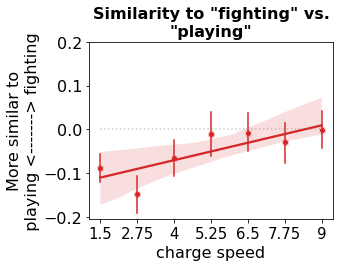

In [26]:
# nrows,ncols = 2,3
# fig,axs = plt.subplots(nrows = 2, ncols = 3, figsize = (12,6), sharey = False)
fig,ax = plt.subplots(nrows=1,ncols=1,figsize = (5,4))

word = 'fight_play'#'play_fight'
sns.lineplot(data=df.reset_index(),x = param_name,y = 'similarity_' + word,\
    ax=ax,marker = 'o', ls = 'None', color = color_plots, err_style='bars')
sns.regplot(data=df.groupby([param_name]).mean().reset_index(),x = param_name,y = 'similarity_' + word,\
    ax=ax,marker = 'o', color = color_plots)
ax.set_xticks(np.unique(df[param_name]),['1.5','2.75','4','5.25','6.5','7.75','9'],fontsize=15, ha='center')
if word != 'fight_play':#'play_fight':
    ax.set_title(f'"{word}" similarity', fontweight = 'bold')
    ax.set_yticks([0.1,0.2,0.3,0.4,.5])
else:
    ax.set_title(f'Similarity to "fighting" vs.\n"playing"', fontweight = 'bold')
    ax.hlines(0,1.5,9,color = 'grey',ls = ':',alpha=.4)
    ax.set_yticks([-.2,-.1,0,0.1,0.2])
ax.set_ylabel('More similar to\n  playing <-----> fighting  ')
ax.set_xlabel('charge speed')
# ax.set_xticks(np.arange(1.5,9.1,1.25),['1.5','2.75','4','5.25','6.5','7.75','9'])
# ax.invert_xaxis()

plt.tight_layout()
plt.savefig(f'{out_loc}word_similarity.png',dpi=300,bbox_inches ='tight')

### Stat + plots

In [159]:
from pymer4.models import Lmer
from pymer4.stats import vif
from scipy.stats import zscore

In [160]:
# df['chargeSpeed'] = zscore(df['chargeSpeed'])
df['chargeSpeed'] = df['chargeSpeed'] - 1.5
df['chargeSpeed'] = df['chargeSpeed']/7.5
df

,subID,stimset_rows,chargeSpeed,responses,movie,trial_num,similarity_playing,similarity_fighting,similarity_fight_play
6,24000,22,0.0,playing,81e3fe3f-5a7c-42d3-8ea7-c2bf3831288b,6,1.000000,0.465401,-0.534599
6,24001,5,0.0,dancing,b3a507ff-2289-4ad3-8922-1a3d0532e154,6,0.450279,0.384975,-0.065305
5,24003,85,0.0,aimlessly running around,1b1159fc-de2b-4ae5-a736-d98d8524a366,5,0.357173,0.333361,-0.023812
3,24004,88,0.0,bumping,38ad4b16-44e2-4e52-8d02-b23eca73a48d,3,0.317942,0.333545,0.015603
6,24005,27,0.0,moving NW and slowly meeting,8ed7c0fc-1490-4e35-a000-7f7357a0772a,6,0.185542,0.177644,-0.007898
...,...,...,...,...,...,...,...,...,...
2,24097,84,1.0,wrestling,a5228b86-ba0a-42f2-aa38-23b5369f0e56,2,0.366225,0.550645,0.184419
4,24098,41,1.0,Using the same playground equipment,7d40f846-95bc-4c08-b7a1-b4a410852b77,4,0.271843,0.049816,-0.222027
6,24099,86,1.0,They are colliding to each other.,6e2932f2-a9d1-4f2a-9599-a872b605c1eb,6,0.274241,0.359482,0.085241
1,24100,71,1.0,playing,7a2ccf3c-feb4-4b5c-9c03-44c10f774f9a,1,1.000000,0.465401,-0.534599


In [161]:
ref_words

['playing', 'fighting', 'fight_play']

In [162]:
model = Lmer(f'similarity_{ref_words[0]} ~ chargeSpeed +  (1|subID) + (1|movie)', data=df) # ff: anglesm rfx: subject ID
model.fit()

boundary (singular) fit: see ?isSingular 

Formula: similarity_playing~chargeSpeed+(1|subID)+(1|movie)

Family: gaussian	 Inference: parametric

Number of observations: 705	 Groups: {'movie': 140.0, 'subID': 102.0}

Log-likelihood: 168.628 	 AIC: -337.255

Random effects:

                 Name    Var    Std
movie     (Intercept)  0.000  0.000
subID     (Intercept)  0.013  0.116
Residual               0.029  0.170

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),0.410,0.378,0.442,0.016,233.853,24.934,0.00,***
chargeSpeed,-0.021,-0.059,0.017,0.019,603.554,-1.080,0.28,


In [163]:
model = Lmer(f'similarity_{ref_words[0]} ~ chargeSpeed +  (1|subID)', data=df) # ff: anglesm rfx: subject ID
model.fit()

Formula: similarity_playing~chargeSpeed+(1|subID)

Family: gaussian	 Inference: parametric

Number of observations: 705	 Groups: {'subID': 102.0}

Log-likelihood: 168.628 	 AIC: -337.255

Random effects:

                 Name    Var    Std
subID     (Intercept)  0.013  0.116
Residual               0.029  0.170

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),0.410,0.378,0.442,0.016,233.853,24.934,0.00,***
chargeSpeed,-0.021,-0.059,0.017,0.019,603.554,-1.080,0.28,


In [164]:
model = Lmer(f'similarity_{ref_words[1]} ~ chargeSpeed +  (1|subID) + (1|movie)', data=df) # ff: anglesm rfx: subject ID
model.fit()

Formula: similarity_fighting~chargeSpeed+(1|subID)+(1|movie)

Family: gaussian	 Inference: parametric

Number of observations: 705	 Groups: {'movie': 140.0, 'subID': 102.0}

Log-likelihood: 168.197 	 AIC: -336.395

Random effects:

                 Name    Var    Std
movie     (Intercept)  0.000  0.016
subID     (Intercept)  0.009  0.093
Residual               0.030  0.174

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),0.300,0.269,0.330,0.015,158.784,19.528,0.0,***
chargeSpeed,0.099,0.059,0.139,0.020,104.334,4.880,0.0,***


In [165]:
model = Lmer(f'similarity_{ref_words[1]} ~ chargeSpeed +  (1|subID) ', data=df) # ff: anglesm rfx: subject ID
model.fit()

Formula: similarity_fighting~chargeSpeed+(1|subID)

Family: gaussian	 Inference: parametric

Number of observations: 705	 Groups: {'subID': 102.0}

Log-likelihood: 168.157 	 AIC: -336.315

Random effects:

                 Name    Var    Std
subID     (Intercept)  0.009  0.093
Residual               0.031  0.175

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),0.300,0.27,0.329,0.015,295.302,19.745,0.0,***
chargeSpeed,0.099,0.06,0.138,0.020,604.342,4.953,0.0,***


In [166]:
model = Lmer(f'similarity_{ref_words[2]} ~ chargeSpeed  +  (1|subID) + (1|movie)', data=df) # ff: anglesm rfx: subject ID
model.fit()

Formula: similarity_fight_play~chargeSpeed+(1|subID)+(1|movie)

Family: gaussian	 Inference: parametric

Number of observations: 705	 Groups: {'movie': 140.0, 'subID': 102.0}

Log-likelihood: 51.546 	 AIC: -103.093

Random effects:

                 Name    Var    Std
movie     (Intercept)  0.003  0.054
subID     (Intercept)  0.005  0.072
Residual               0.043  0.208

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),-0.109,-0.144,-0.073,0.018,158.628,-5.978,0.0,***
chargeSpeed,0.120,0.066,0.174,0.028,119.039,4.335,0.0,***


In [167]:
model = Lmer(f'similarity_{ref_words[2]} ~ chargeSpeed  +  (1|subID) ', data=df) # ff: anglesm rfx: subject ID
model.fit()

Formula: similarity_fight_play~chargeSpeed+(1|subID)

Family: gaussian	 Inference: parametric

Number of observations: 705	 Groups: {'subID': 102.0}

Log-likelihood: 49.062 	 AIC: -98.125

Random effects:

                 Name    Var    Std
subID     (Intercept)  0.006  0.075
Residual               0.046  0.214

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),-0.111,-0.143,-0.078,0.017,408.570,-6.679,0.0,***
chargeSpeed,0.120,0.072,0.168,0.024,605.689,4.919,0.0,***
